###Görüntü İşleme Laboratuvarı: Uygulama Çalışması (TP)
Bu çalışma, Python ve OpenCV kullanarak temel görüntü işleme tekniklerini uygulamanız için hazırlanmıştır. Kodları yazmadan önce size verilen "Teorik Notlar" kısmındaki fonksiyonları ve kullanım şekillerini dikkatlice inceleyiniz.


Bölüm 1: Görüntü Okuma, Özellikler ve Piksel İşlemleri
Bu bölümde bir görüntünün belleğe yüklenmesi, meta verilerinin analizi ve temel matris manipülasyonlarını gerçekleştireceksiniz.

Görevler:

lena.jpg görüntüsünü okuyun ve görüntüleyin.

Görüntünün boyut (shape), toplam piksel (size) ve veri tipi (dtype) bilgilerini ekrana yazdırın.

Görüntüyü gri seviyeye ve HSV uzayına dönüştürün. Elde ettiğiniz sonuçları diske kaydedin.



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [54]:
image = cv2.imread("lena.png")

In [55]:
print(image.shape)
print(image.size)
print(image.dtype)

(512, 512, 3)
786432
uint8


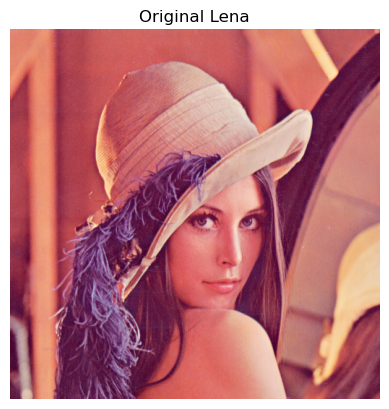

In [56]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Lena")
plt.axis('oFF') # Eksenleri gizlemek istersen
plt.show()

In [57]:
lena_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

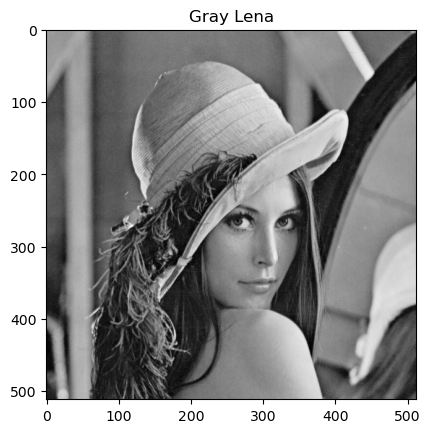

In [58]:
plt.imshow(lena_gray, cmap='gray')
plt.title("Gray Lena")
plt.axis('on') # Eksenleri gizlemek istersen
plt.show()

In [39]:
cv2.imwrite("lena_gray.jpg", lena_gray)

True

In [40]:
lena_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

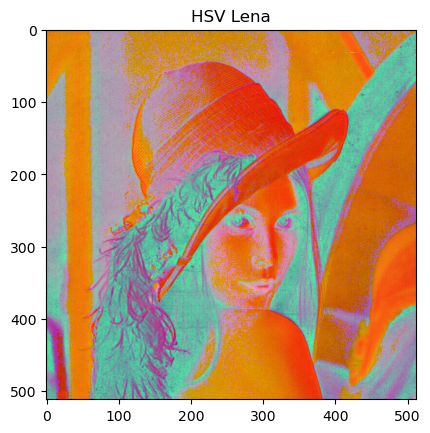

In [41]:
plt.imshow(cv2.cvtColor(lena_hsv, cv2.COLOR_BGR2RGB))
plt.title("HSV Lena")
plt.axis('on') # Eksenleri gizlemek istersen
plt.show()

In [42]:
cv2.imwrite("lena_hsv.jpg", lena_hsv)

True

Görüntü üzerinde [200:300, 200:300] bölgesini dilimleyerek (slicing) "cropped" isimli yeni bir değişkene atayın ve gösterin.

Orijinal görüntünün [100:150, 50:100] koordinatlarındaki piksellerini tam yeşil (RGB formatına dikkat!) yapın ve sonucu ekranda görün.

Görüntüyü JPEG formatında, 0'dan 100'e kadar 10'ar adımlık (0, 10, 20...) kalite parametreleri ile farklı dosyalara kaydedin.

In [43]:
cropped = image[200:300, 200:300]

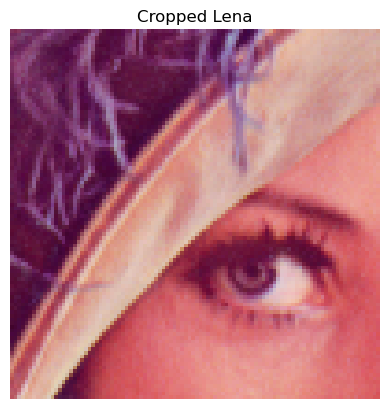

In [44]:
plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title("Cropped Lena")
plt.axis('off') # Eksenleri gizlemek istersen
plt.show()

In [77]:
image[100:150, 50:100] = (0,255,0)

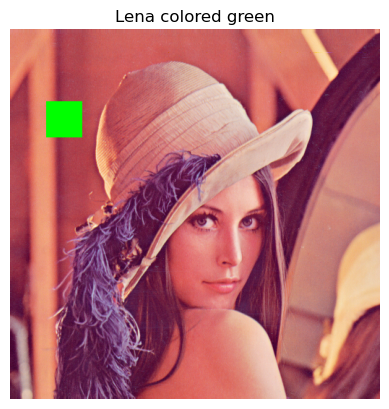

In [78]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Lena colored green")
plt.axis('oFF') # Eksenleri gizlemek istersen
plt.show()

In [82]:
def calculate_mse(img1, img2):
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    mse = np.mean(diff**2)
    return mse

In [86]:
mse_values = [] 
for q in range(0, 101, 10):
    file_name = f"lena_q{q}.jpg"
    cv2.imwrite(file_name, image, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    compressed = cv2.imread(file_name)
    mse_values.append(calculate_mse(image, compressed))

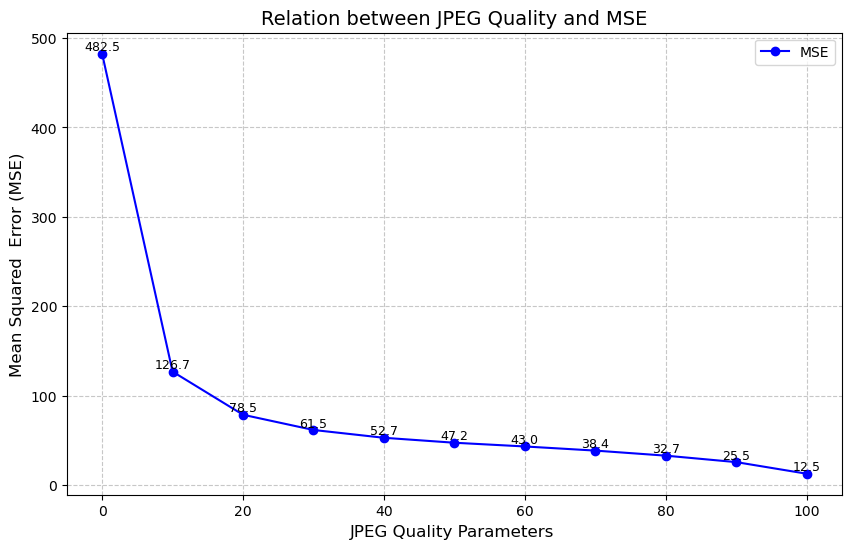

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

qualities = list(range(0, 101, 10))

plt.plot(qualities, mse_values, marker='o', linestyle='-', color='b', label='MSE')

plt.title("Relation between JPEG Quality and MSE", fontsize=14)
plt.xlabel("JPEG Quality Parameters ", fontsize=12)
plt.ylabel("Mean Squared  Error (MSE)", fontsize=12)

# grid
plt.grid(True, linestyle='--', alpha=0.7)

# Veri noktalarının üzerine değerleri yazdırma
for i, val in enumerate(mse_values):
    plt.text(qualities[i], mse_values[i], f'{val:.1f}', va='bottom', ha='center', fontsize=9)
plt.legend()
plt.show()


#  Soru: Kalite düştükçe MSE (Mean Squared Error / EQM) değerinin nasıl değişmesini beklersiniz?
#  Cevap: Kalite düştükçe MSE nin artması beklenir çünkü original image a benzerlik gittikçe azalacaktır

Görüntülerin boyutlandırılması ve koordinat düzlemindeki hareketlerini inceleyeceksiniz.


Gri seviyeli görüntüyü orijinal boyutunun 2 katı olacak şekilde yeniden boyutlandırın.

Görüntüyü yatayda 100 piksel, dikeyde 50 piksel öteleyen (translation) affine dönüşümünü uygulayın.

Görüntüyü kendi merkezi etrafında 45 derece döndürün.

İpucu: Dönüşüm matrislerinin (M) oluşturulması ve warpAffine kullanımı için notlardaki ilgili kısımları inceleyiniz.


Orijinal lena görüntüsü ile bu görüntünün farklı kalite parametreleri (Quality: 10 ve Quality: 90) kullanılarak kaydedilmiş halleri arasındaki farkı matematiksel olarak nasıl ölçeriz? Kalite düştükçe MSE (Mean Squared Error / EQM) değerinin nasıl değişmesini beklersiniz? Lütfen Quality: 10 ve Quality: 90 arasındaki resimler için MSE değerini hesaplayan kodu yazınız ve MSE değerlerindeki değişimi bir grafiğe aktarınız.

In [61]:
# Kalitesi düsmemesi icin interpolation parametresi eklendi
lena_gray = cv2.resize(lena_gray, (1024, 1024), interpolation=cv2.INTER_CUBIC)

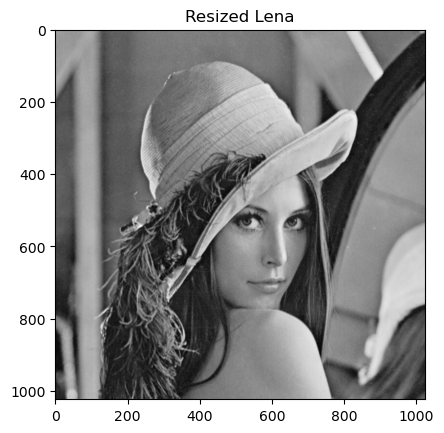

In [62]:
plt.imshow(lena_gray, cmap='gray')
plt.title("Resized Lena")
plt.axis('on')
plt.show()

In [69]:
# 1. Öteleme matrisini tanımlama
tx = 100
ty = 50
M = np.float32([[1, 0, tx], 
                [0, 1, ty]])

# görüntü boyutları tutuma
(h, w) = lena_gray.shape[:2]

translated_lena = cv2.warpAffine(lena_gray, M, (w, h))

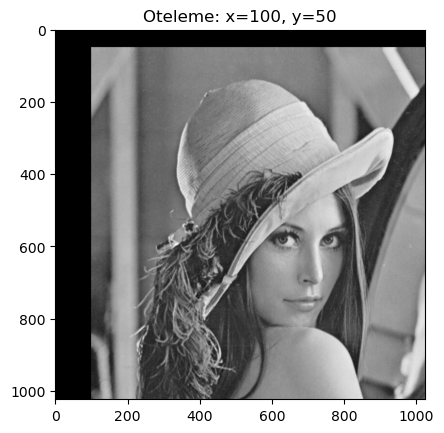

In [70]:
plt.imshow(translated_lena, cmap='gray')
plt.axis('on')
plt.title(f"Oteleme: x={tx}, y={ty}")
plt.show()

In [73]:
(h_rot, w_rot) = translated_lena.shape[:2]
center_rot = (w_rot // 2, h_rot // 2)
# Döndürme matrisini olusturma: 45 derece, ölçeklendirme yok (1.0)
M_rot = cv2.getRotationMatrix2D(center_rot, 45, 1.0)


rotated_translated_lena = cv2.warpAffine(translated_lena, M_rot, (w_rot, h_rot))

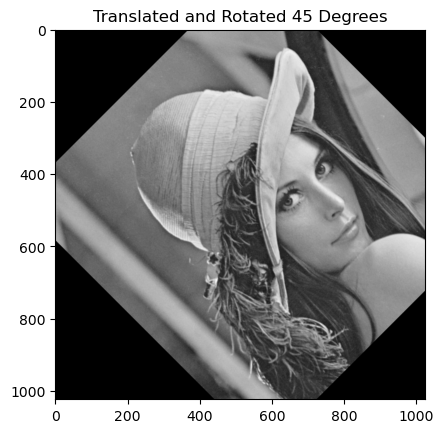

In [74]:
plt.imshow(rotated_translated_lena, cmap='gray')
plt.axis('on')
plt.title("Translated and Rotated 45 Degrees")
plt.show()

Bölüm 3: Histogram ve Eşikleme (Rehaussement)
Görüntüdeki yoğunluk dağılımını analiz ederek nesne ayırma (segmentasyon) adımlarına giriş yapacaksınız.

Görevler:

avion.jpg görüntüsünü okuyun.

Görüntünün minimum ve maksimum yoğunluk değerlerini numpy fonksiyonları ile bulun ve ekrana yazdırın.

Görüntünün histogramını hesaplayın. matplotlib kullanarak histogram grafiğini çizin ve .png formatında kaydedin.

cv2.threshold komutunu kullanarak manuel bir eşik değeri belirleyin. Görüntüyü siyah-beyaz (binary) hale getirin.

Yorum Sorusu: Farklı eşik değerleri (örneğin 50, 127, 200) denediğinizde uçaktaki detaylar ve arka plan nasıl değişiyor?

İpucu: Histogram için calcHist, eşikleme için threshold fonksiyonlarını notlardan kontrol ediniz.

In [98]:
avion = cv2.imread("avion.jpg")

In [100]:
min_value = np.min(avion)
max_value = np.max(avion)

print(min_value)
print(max_value)

0
245


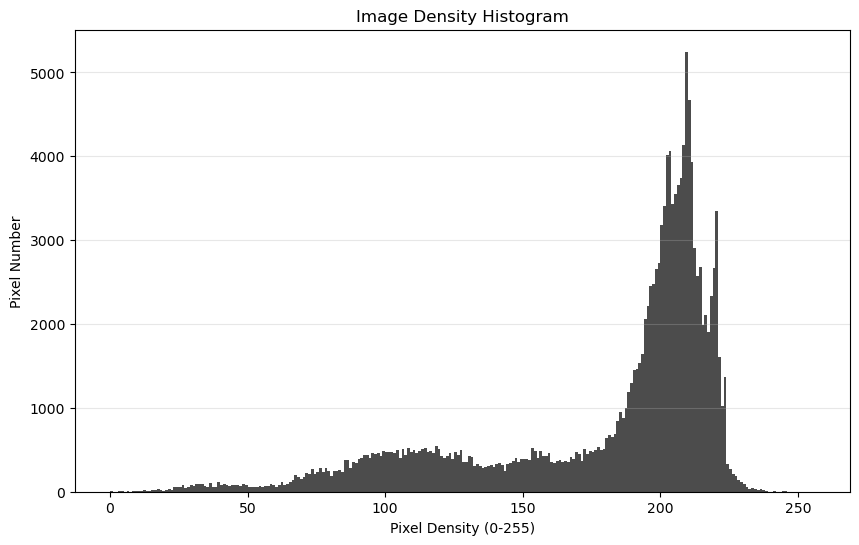

In [106]:
plt.figure(figsize=(10, 6))
plt.hist(avion.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7) 
# grafik yapacağım için matplotlib in fonksiyonunu kullanmak daha rahat geldi
plt.title("Image Density Histogram")
plt.xlabel("Pixel Density (0-255)")
plt.ylabel("Pixel Number")
plt.grid(axis='y', alpha=0.3)

plt.savefig("avion_hist.png")
plt.show()

In [118]:
threshold_value = 127 #50 127 200
ret, thresh_img = cv2.threshold(avion, threshold_value, 255, cv2.THRESH_BINARY)

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

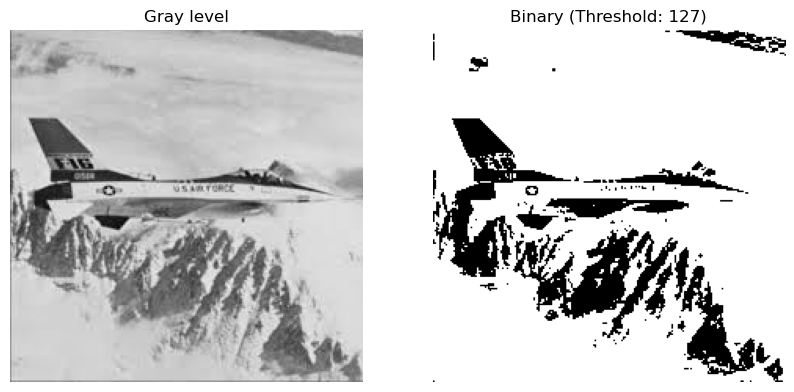

In [119]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(avion, cmap='gray')
plt.title("Gray level")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thresh_img, cmap='gray')
plt.title(f"Binary (Threshold: {threshold_value})")
plt.axis('off')

In [120]:
# 50  uçağın varlığı pek anlaşılmıyor , dağ yapamcı görünmüyor
# 127 uçak ve dağın yamacı belirginleşiyor
# 200 uçak ve dağın yamacına ek olarak bulutlar da siyah oluyor ve ayırt edicilik azalıyor